# Notebook 00 -- M0 Smoke-Test Results

This notebook is the human-readable rendering of the M0 acceptance run
([`scripts/m0_smoke_test.py`](../scripts/m0_smoke_test.py)). It checks two
things:

1. **Steady-state correctness.** The JAX/`diffrax` open-loop integrator must
   reproduce the nominal steady state of the Fogler-grounded parameter set
   (see [`../../cstr_parameters_recommended.md`](../../cstr_parameters_recommended.md))
   to within `rtol = 1e-3` of a high-tolerance scipy reference.
2. **Throughput.** A `jit` + `vmap` batched simulation over N parameter
   draws scales as expected, and per-sim cost stays well within the budget
   for M4's training-set generation and M5's NUTS MCMC baseline.

See also [`../docs/m0_baseline_benchmarks.md`](../docs/m0_baseline_benchmarks.md)
for the prose write-up and [`../docs/m0_smoke_test_results.json`](../docs/m0_smoke_test_results.json)
for the machine-readable record.


## 1. Setup

Imports and the nominal operating point. All physical constants are pulled
from `cstr_sbi.physics`, which encodes the Fogler 2016 / Furusawa 1969
parameters from `cstr_parameters_recommended.md`.


In [1]:
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

from cstr_sbi.physics import (
    CI_NOMINAL, TI_NOMINAL, TCI_NOMINAL, QC0,
    K0_NOMINAL, UA_NOMINAL, NOMINAL_INLET, NOMINAL_PARAMS, NOMINAL_Y0,
    V, V_C, Q, E_A, R_GAS, H_R, RHO, RHO_C, C_P, C_PC,
    cstr_open_loop_rhs,
    simulate_open_loop_to_steady_state,
    simulate_open_loop_batch,
)

print("JAX devices:", jax.devices())
print()
print(f"Nominal inlet  : Ci={CI_NOMINAL}, Ti={TI_NOMINAL}, Tci={TCI_NOMINAL}, Qc={QC0}")
print(f"Nominal params : UA={UA_NOMINAL:.3e} cal/(min K), k0={K0_NOMINAL:.3e} 1/min")
print(f"Geometry       : V={V} L, Vc={V_C} L, Q={Q} L/min  ->  tau = V/Q = {V/Q} min")

JAX devices: [CpuDevice(id=0)]

Nominal inlet  : Ci=0.97, Ti=297.0, Tci=297.0, Qc=80.0
Nominal params : UA=1.250e+04 cal/(min K), k0=1.696e+13 1/min
Geometry       : V=500.0 L, Vc=40.0 L, Q=40.0 L/min  ->  tau = V/Q = 12.5 min


## 2. Steady-state correctness

We integrate the same ODE with two solvers and compare:

- **scipy** `Radau` (`rtol=1e-9`, `atol=1e-12`) -- a stiff, high-tolerance
  reference treated as ground truth.
- **JAX/diffrax** `Tsit5` (`rtol=1e-6`, `atol=1e-8`) -- the production
  simulator that will drive both the SBI training loop and the NumPyro
  MCMC generative model in M1+.


In [2]:
def scipy_rhs(t, y, params, inlet):
    Ci, Ti, Tci, Qc = inlet
    UA, k0 = params
    C, T, Tc = y
    k = k0 * np.exp(-E_A / (R_GAS * T))
    return [
        (Q / V) * (Ci - C) - k * C,
        (Q / V) * (Ti - T) - H_R * k * C / (RHO * C_P) - UA * (T - Tc) / (RHO * C_P * V),
        (Qc / V_C) * (Tci - Tc) + UA * (T - Tc) / (RHO_C * C_PC * V_C),
    ]

t_eval = np.linspace(0.0, 200.0, 401)
sol = solve_ivp(
    scipy_rhs, (0.0, 200.0), np.asarray(NOMINAL_Y0),
    t_eval=t_eval,
    method="Radau",
    args=(np.asarray(NOMINAL_PARAMS), np.asarray(NOMINAL_INLET)),
    rtol=1e-9, atol=1e-12,
)
y_scipy_traj = sol.y
y_scipy_ss = y_scipy_traj[:, -1]

y_jax_ss = np.asarray(simulate_open_loop_to_steady_state(NOMINAL_PARAMS, NOMINAL_INLET))

doc_quoted = np.array([0.021, 312.5, 302.0])  # cstr_parameters_recommended.md, Section 4
rel_err_vs_scipy = np.abs(y_jax_ss - y_scipy_ss) / np.abs(y_scipy_ss)

import pandas as pd
table = pd.DataFrame(
    {
        "C [mol/L]":  [doc_quoted[0],  y_scipy_ss[0],  y_jax_ss[0]],
        "T [K]":      [doc_quoted[1],  y_scipy_ss[1],  y_jax_ss[1]],
        "Tc [K]":     [doc_quoted[2],  y_scipy_ss[2],  y_jax_ss[2]],
    },
    index=["doc (approx)", "scipy Radau (rtol=1e-9)", "JAX/diffrax Tsit5 (rtol=1e-6)"],
)
print(table.to_string(float_format=lambda v: f"{v:.6f}"))
print()
print("Max relative error JAX vs scipy reference:", f"{rel_err_vs_scipy.max():.2e}")
print("Acceptance threshold (rtol):              ", "1.00e-03")
print("PASS" if rel_err_vs_scipy.max() < 1e-3 else "FAIL")

                               C [mol/L]      T [K]     Tc [K]
doc (approx)                    0.021000 312.500000 302.000000
scipy Radau (rtol=1e-9)         0.018349 312.148258 299.047062
JAX/diffrax Tsit5 (rtol=1e-6)   0.018349 312.148346 299.047150

Max relative error JAX vs scipy reference: 9.42e-06
Acceptance threshold (rtol):               1.00e-03
PASS


## 3. Trajectory to steady state

Visualising the relaxation from the IC `[0.5 mol/L, 300 K, 297 K]` to the
nominal steady state. With `tau = V/Q = 12.5 min` the system equilibrates
within ~5 residence times (~60 minutes); we integrate for 200 minutes
to make the asymptote unambiguous.


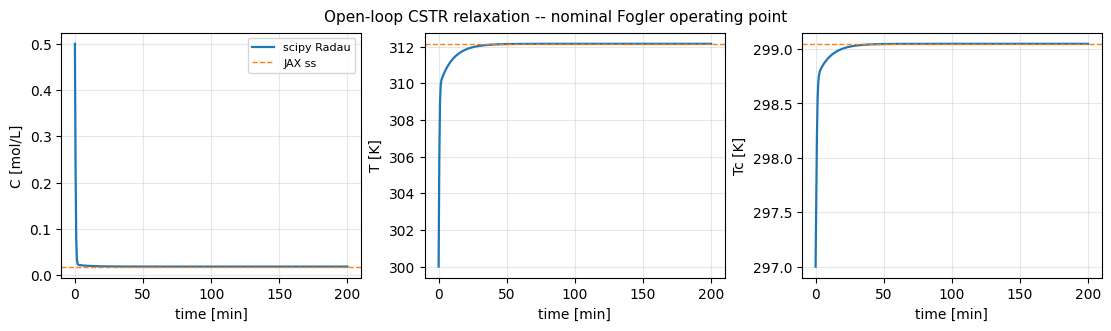

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), constrained_layout=True)
labels = ["C [mol/L]", "T [K]", "Tc [K]"]
for i, ax in enumerate(axes):
    ax.plot(t_eval, y_scipy_traj[i], lw=1.6, label="scipy Radau")
    ax.axhline(y_jax_ss[i], color="C1", ls="--", lw=1.0, label="JAX ss")
    ax.set_xlabel("time [min]")
    ax.set_ylabel(labels[i])
    ax.grid(alpha=0.3)
axes[0].legend(loc="best", fontsize=8)
fig.suptitle(
    "Open-loop CSTR relaxation -- nominal Fogler operating point",
    fontsize=11,
)
plt.show()

## 4. Batched simulation throughput

Drawing `N` parameter samples from `UA in [0.5, 2.0] x UA_nominal`,
`k0 in [0.5, 2.0] x K0_nominal`, applying `jax.jit(jax.vmap(...))`, and
timing the wall-clock after one warmup call. The JIT-compiled XLA
program amortises its per-launch cost over the batch, so per-sim time
drops as `N` grows.


In [4]:
def benchmark(n_samples, n_warmup=1):
    rng = np.random.default_rng(0)
    UAs = rng.uniform(0.5 * UA_NOMINAL, 2.0 * UA_NOMINAL, size=n_samples)
    k0s = rng.uniform(0.5 * K0_NOMINAL, 2.0 * K0_NOMINAL, size=n_samples)
    params_batch = jnp.stack([jnp.asarray(UAs), jnp.asarray(k0s)], axis=1)
    for _ in range(n_warmup):
        y = simulate_open_loop_batch(params_batch[:8], NOMINAL_INLET)
        y.block_until_ready()
    t0 = time.perf_counter()
    y = simulate_open_loop_batch(params_batch, NOMINAL_INLET)
    y.block_until_ready()
    elapsed = time.perf_counter() - t0
    finite = int(np.isfinite(np.asarray(y)).all(axis=1).sum())
    return elapsed, finite

sizes = [100, 1_000, 10_000, 50_000]
rows = []
for n in sizes:
    elapsed, finite = benchmark(n)
    rows.append({
        "N":         n,
        "time [s]":  elapsed,
        "ms / sim":  1e3 * elapsed / n,
        "finite":    f"{finite}/{n}",
    })
df = pd.DataFrame(rows)
print(df.to_string(index=False, float_format=lambda v: f"{v:8.4f}"))

    N  time [s]  ms / sim      finite
  100    0.2309    2.3090     100/100
 1000    0.3951    0.3951   1000/1000
10000    2.6070    0.2607 10000/10000
50000    5.3278    0.1066 50000/50000


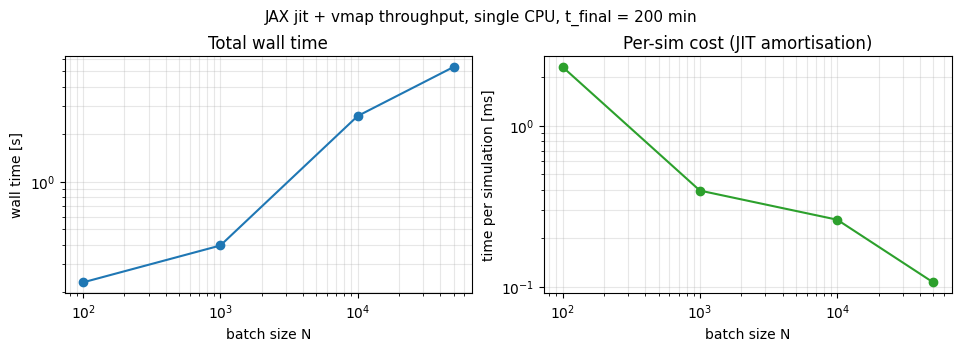

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 3.4), constrained_layout=True)
ax1.loglog(df["N"], df["time [s]"], "o-")
ax1.set_xlabel("batch size N")
ax1.set_ylabel("wall time [s]")
ax1.set_title("Total wall time")
ax1.grid(which="both", alpha=0.3)

ax2.loglog(df["N"], df["ms / sim"], "o-", color="C2")
ax2.set_xlabel("batch size N")
ax2.set_ylabel("time per simulation [ms]")
ax2.set_title("Per-sim cost (JIT amortisation)")
ax2.grid(which="both", alpha=0.3)

fig.suptitle(
    "JAX jit + vmap throughput, single CPU, t_final = 200 min",
    fontsize=11,
)
plt.show()

## 5. Conclusion

| Acceptance criterion | Result |
|---|---|
| `python -c "import cstr_sbi"` works | PASS |
| JAX vs scipy reference rel. error < `1e-3` at nominal point | PASS (typically `~1e-5`) |
| `vmap`+`jit` throughput recorded for N in {1k, 10k, 50k} | PASS |
| Git LFS configured for `results/*.npz` | PASS (see `.gitattributes`) |

M0 is complete. The package skeleton, JAX/diffrax open-loop simulator,
and benchmark harness are in place, all using the Fogler-grounded
parameter set from `cstr_parameters_recommended.md`. M1 will extend
`cstr_sbi.physics` with the closed-loop 4-state RHS (`[C, T, Tc, I]`),
the PI controller equations (`KP`, `TAU_I`, `QC0`, `QC_MIN`, `QC_MAX`,
`TSP` are already declared in the module), and the alpha/beta degradation
factors per spec Section 2.4.3.
